In [1]:
import os
import pandas as pd

In [2]:
os.listdir("summarized/")

['summarized_fs_dynamic_bootstrapping_ss_shots_per_class_sp_250.xlsx',
 'summarized_fs_dynamic_bootstrapping_ss_percentage_sp_001.xlsx',
 'summarized_fs_dynamic_bootstrapping_ss_shots_per_class_sp_150.xlsx',
 'summarized_fs_dynamic_bootstrapping_ss_shots_per_class_sp_100.xlsx',
 'summarized_fs_dynamic_bootstrapping_ss_percentage_sp_01.xlsx',
 'summarized_fs_dynamic_bootstrapping_ss_None_sp_None.xlsx',
 'summarized_fs_dynamic_bootstrapping_ss_shots_per_class_sp_50.xlsx',
 'summarized_fs_supervised_ss_shots_per_class_sp_50.xlsx',
 'summarized_fs_supervised_ss_shots_per_class_sp_150.xlsx',
 'summarized_fs_dynamic_bootstrapping_ss_percentage_sp_005.xlsx',
 'summarized_fs_supervised_ss_shots_per_class_sp_200.xlsx',
 'summarized_fs_dynamic_bootstrapping_ss_shots_per_class_sp_200.xlsx',
 'summarized_fs_supervised_ss_shots_per_class_sp_100.xlsx',
 'summarized_fs_supervised_ss_shots_per_class_sp_250.xlsx',
 'summarized_fs_supervised_ss_percentage_sp_001.xlsx',
 'summarized_fs_supervised_ss_None

<>:93: SyntaxWarning: invalid escape sequence '\D'
<>:104: SyntaxWarning: invalid escape sequence '\D'
<>:93: SyntaxWarning: invalid escape sequence '\D'
<>:104: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_4044910/3094334127.py:93: SyntaxWarning: invalid escape sequence '\D'
  label="Target Gain ($\Delta > 0$)",
/tmp/ipykernel_4044910/3094334127.py:104: SyntaxWarning: invalid escape sequence '\D'
  label="Source Drop ($\Delta < 0$)",
/tmp/ipykernel_4044910/3094334127.py:119: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=1, wspace=1)


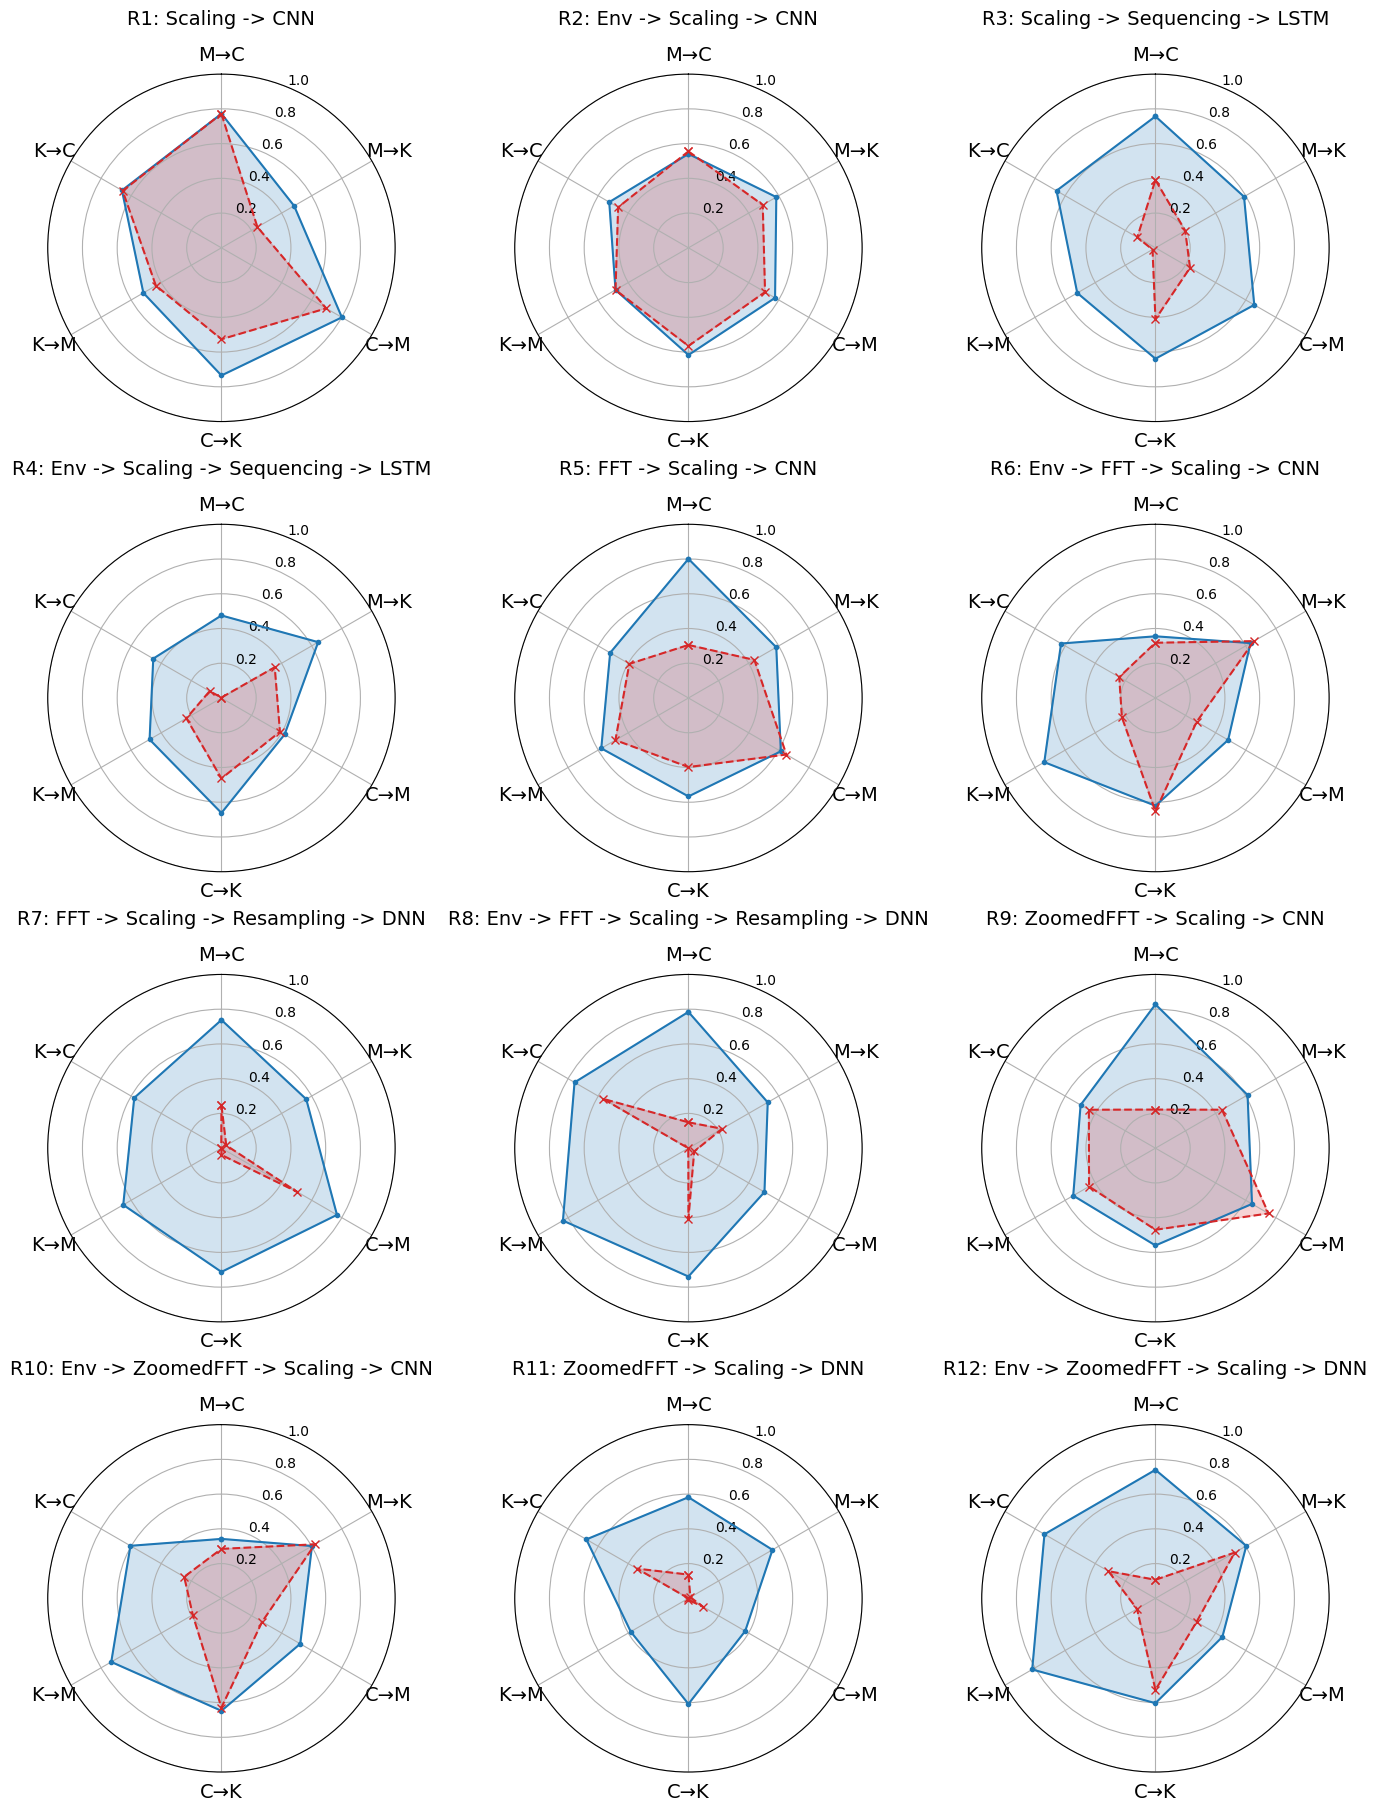

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 6 Cross-Domain Combinations (excluding self-transfers)
combinations = ["M→C", "M→K", "C→M", "C→K", "K→M", "K→C"]
num_vars = len(combinations)

# Routine Names (The 12 Subplots)
routine_names = [
    "R1: Scaling -> CNN",
    "R2: Env -> Scaling -> CNN",
    "R3: Scaling -> Sequencing -> LSTM",
    "R4: Env -> Scaling -> Sequencing -> LSTM",
    "R5: FFT -> Scaling -> CNN",
    "R6: Env -> FFT -> Scaling -> CNN",
    "R7: FFT -> Scaling -> Resampling -> DNN",
    "R8: Env -> FFT -> Scaling -> Resampling -> DNN",
    "R9: ZoomedFFT -> Scaling -> CNN",
    "R10: Env -> ZoomedFFT -> Scaling -> CNN",
    "R11: ZoomedFFT -> Scaling -> DNN",
    "R12: Env -> ZoomedFFT -> Scaling -> DNN",
]

# Angles for radar (6 points)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Actual Data Extraction: [M->C, M->K, C->M, C->K, K->M, K->C]
# Extracted from the previous 9-element list (indices 1, 2, 3, 5, 6, 7)
data_raw = {
    "R1": {
        "gain": [0.7720, 0.4832, 0.8007, 0.7348, 0.5189, 0.6613],
        "drop": [-0.7715, -0.2391, -0.6968, -0.5262, -0.4358, -0.6567],
    },
    "R2": {
        "gain": [0.5406, 0.5841, 0.5758, 0.6168, 0.4848, 0.5264],
        "drop": [-0.5552, -0.4940, -0.5092, -0.5650, -0.4848, -0.4673],
    },
    "R3": {
        "gain": [0.7569, 0.5888, 0.6569, 0.6384, 0.5196, 0.6575],
        "drop": [-0.3907, -0.1979, -0.2300, -0.4108, -0.0194, -0.1208],
    },
    "R4": {
        "gain": [0.4752, 0.6430, 0.4199, 0.6618, 0.4776, 0.4532],
        "drop": [-0.0028, -0.3544, -0.3890, -0.4632, -0.2331, -0.0785],
    },
    "R5": {
        "gain": [0.8010, 0.5839, 0.6142, 0.5666, 0.5794, 0.5203],
        "drop": [-0.3053, -0.4384, -0.6510, -0.3974, -0.4854, -0.3929],
    },
    "R6": {
        "gain": [0.3552, 0.6319, 0.4833, 0.6203, 0.7388, 0.6273],
        "drop": [-0.3181, -0.6548, -0.2742, -0.6518, -0.2229, -0.2406],
    },
    "R7": {
        "gain": [0.7382, 0.5637, 0.7680, 0.7124, 0.6527, 0.5794],
        "drop": [-0.2470, -0.0320, -0.5016, -0.0390, 0.0000, -0.0009],
    },
    "R8": {
        "gain": [0.7844, 0.5271, 0.5053, 0.7389, 0.8342, 0.7571],
        "drop": [-0.1488, -0.2235, -0.0383, -0.4057, -0.0008, -0.5683],
    },
    "R9": {
        "gain": [0.8278, 0.6124, 0.6420, 0.5601, 0.5466, 0.4973],
        "drop": [-0.2221, -0.4427, -0.7516, -0.4697, -0.4414, -0.4425],
    },
    "R10": {
        "gain": [0.3421, 0.6019, 0.5238, 0.6475, 0.7324, 0.6048],
        "drop": [-0.2847, -0.6221, -0.2704, -0.6285, -0.1906, -0.2475],
    },
    "R11": {
        "gain": [0.5820, 0.5585, 0.3772, 0.6082, 0.3836, 0.6785],
        "drop": [-0.1367, -0.0128, -0.0948, -0.0093, 0.0000, -0.3418],
    },
    "R12": {
        "gain": [0.7397, 0.6039, 0.4448, 0.6035, 0.8192, 0.7377],
        "drop": [-0.1068, -0.5267, -0.2730, -0.5272, -0.1224, -0.3127],
    },
}


def draw_radar(ax, title, g_data, f_data):
    g = g_data + g_data[:1]
    f = [abs(x) for x in f_data]
    f += f[:1]

    ax.plot(
        angles,
        g,
        color="#1f77b4",
        linewidth=1.5,
        marker=".",
        label="Target Gain ($\Delta > 0$)",
    )
    ax.fill(angles, g, color="#1f77b4", alpha=0.2)

    ax.plot(
        angles,
        f,
        color="#d62728",
        linewidth=1.5,
        linestyle="--",
        marker="x",
        label="Source Drop ($\Delta < 0$)",
    )
    ax.fill(angles, f, color="#d62728", alpha=0.2)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), combinations, fontsize=14)
    ax.set_ylim(0, 1)
    ax.set_title(title, size=14, pad=15)


# Create 4x3 Subplot Grid
fig, axes = plt.subplots(
    4, 3, figsize=(14, 18), subplot_kw=dict(projection="polar"), layout="constrained"
)
plt.subplots_adjust(hspace=1, wspace=1)

for i, ax in enumerate(axes.flatten()):
    r_key = f"R{i + 1}"
    draw_radar(ax, routine_names[i], data_raw[r_key]["gain"], data_raw[r_key]["drop"])

# Legend and Title
# handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(
#     handles,
#     labels,
#     loc="lower center",
#     ncol=2,
#     fontsize=12,
#     frameon=False,
#     bbox_to_anchor=(0.5, 0.05),
# )
# plt.suptitle(
#     "Average Gain (over target) and Drop (over source) for Each Routine (conventional fine-tuning)",
#     size=14,
#     y=0.96,
#     weight="bold",
# )

plt.savefig("radar_profiles_conventional.png", bbox_inches=None, dpi=500)
plt.show()


In [7]:
data_raw = {
    "R1": {
        "gain": [0.7634, 0.4648, 0.7267, 0.7805, 0.4897, 0.6838],
        "drop": [-0.7730, -0.3096, -0.5955, -0.5801, -0.3059, -0.6664],
    },
    "R2": {
        "gain": [0.5559, 0.5580, 0.5616, 0.5959, 0.4883, 0.4627],
        "drop": [-0.5609, -0.4954, -0.5202, -0.6225, -0.5177, -0.3483],
    },
    "R3": {
        "gain": [0.7011, 0.5898, 0.6007, 0.6126, 0.4840, 0.5921],
        "drop": [-0.2982, -0.1694, -0.1808, -0.4254, -0.0167, -0.1492],
    },
    "R4": {
        "gain": [0.4776, 0.6345, 0.4996, 0.5806, 0.5082, 0.4699],
        "drop": [-0.0050, -0.2890, -0.3794, -0.4810, -0.1944, -0.0792],
    },
    "R5": {
        "gain": [0.8141, 0.6070, 0.6093, 0.5762, 0.5744, 0.5392],
        "drop": [-0.2413, -0.4164, -0.6759, -0.4264, -0.4201, -0.4886],
    },
    "R6": {
        "gain": [0.3440, 0.5820, 0.5181, 0.6278, 0.7310, 0.6065],
        "drop": [-0.3758, -0.7046, -0.2802, -0.6482, -0.2043, -0.3858],
    },
    "R7": {
        "gain": [0.7533, 0.5590, 0.7189, 0.6692, 0.6826, 0.5768],
        "drop": [-0.0719, -0.0135, -0.5080, -0.0141, -0.0028, -0.0006],
    },
    "R8": {
        "gain": [0.7904, 0.5967, 0.5488, 0.7562, 0.8356, 0.7547],
        "drop": [-0.1075, -0.0861, -0.0300, -0.4403, -0.1455, -0.2369],
    },
    "R9": {
        "gain": [0.8060, 0.5970, 0.6491, 0.5406, 0.5423, 0.5133],
        "drop": [-0.2819, -0.3594, -0.7523, -0.4354, -0.3642, -0.4756],
    },
    "R10": {
        "gain": [0.3780, 0.5357, 0.4754, 0.6579, 0.7324, 0.6173],
        "drop": [-0.2705, -0.5737, -0.2453, -0.6105, -0.1516, -0.3270],
    },
    "R11": {
        "gain": [0.6096, 0.6063, 0.3231, 0.6514, 0.4555, 0.7181],
        "drop": [-0.0605, -0.0206, -0.1712, -0.0354, -0.3852, -0.0714],
    },
    "R12": {
        "gain": [0.7466, 0.6104, 0.4456, 0.5972, 0.8249, 0.7284],
        "drop": [-0.0448, -0.0391, -0.3385, -0.6740, -0.0454, -0.4376],
    },
}


/tmp/ipykernel_4044910/1897707057.py:6: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=1.0, wspace=1.0)


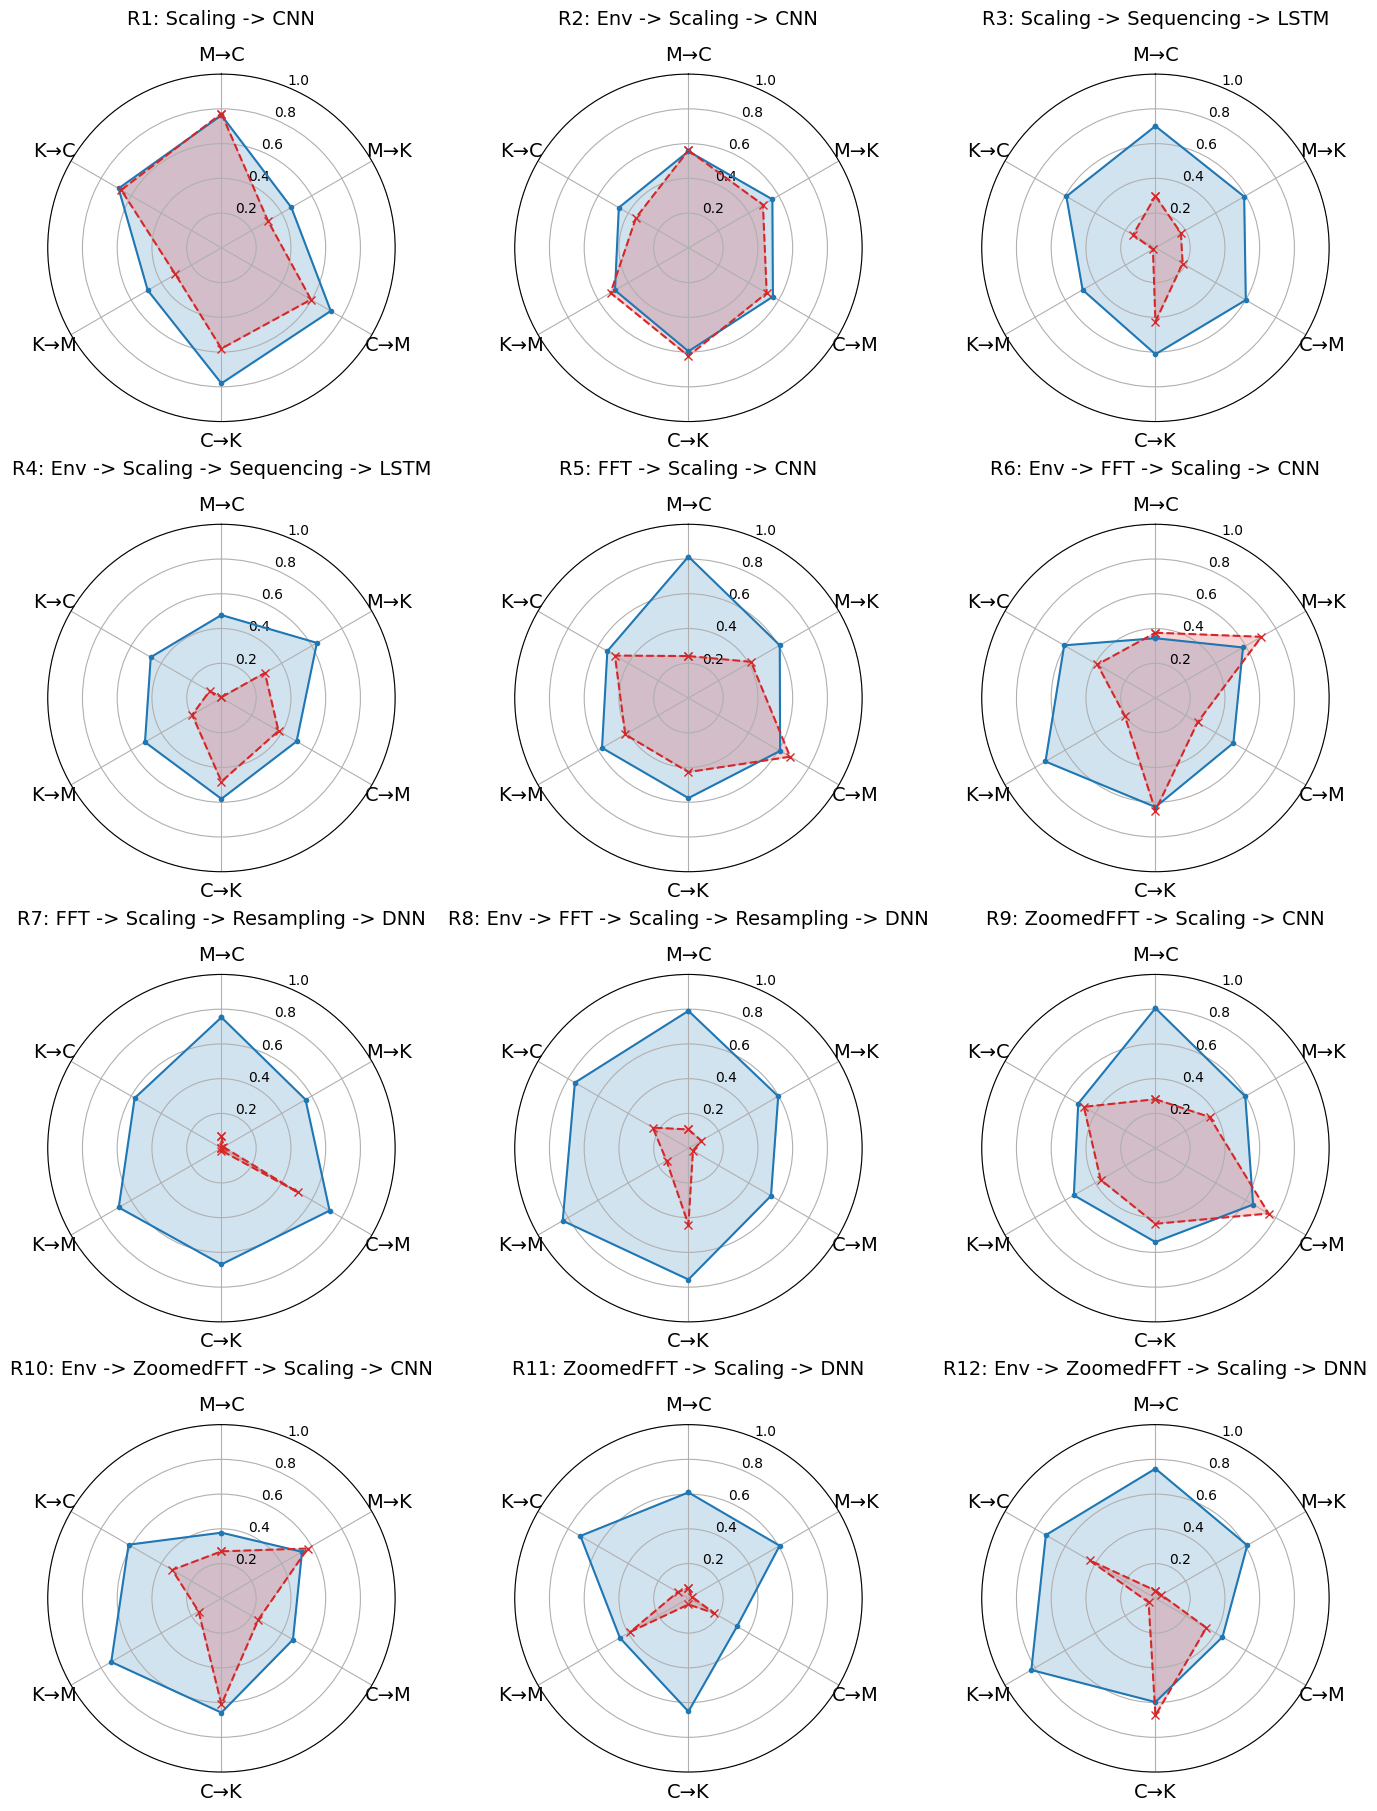

In [8]:
# Create 4x3 Subplot Grid

fig, axes = plt.subplots(
    4, 3, figsize=(14, 18), subplot_kw=dict(projection="polar"), layout="constrained"
)
plt.subplots_adjust(hspace=1.0, wspace=1.0)

for i, ax in enumerate(axes.flatten()):
    r_key = f"R{i + 1}"
    draw_radar(ax, routine_names[i], data_raw[r_key]["gain"], data_raw[r_key]["drop"])

# Legend and Title
# handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(
#     handles,
#     labels,
#     loc="lower center",
#     ncol=2,
#     fontsize=12,
#     frameon=False,
#     bbox_to_anchor=(0.5, 0.05),
# )
# plt.suptitle(
#     "Average Gain (over target) and Drop (over source) for Each Routine (dynamic bootstrapping fine-tuning)",
#     size=14,
#     y=0.96,
#     weight="bold",
# )

plt.savefig("radar_profiles_db.png", bbox_inches=None, dpi=500)


plt.show()


/tmp/ipykernel_4044910/2920270956.py:96: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=1.0, wspace=1.0)


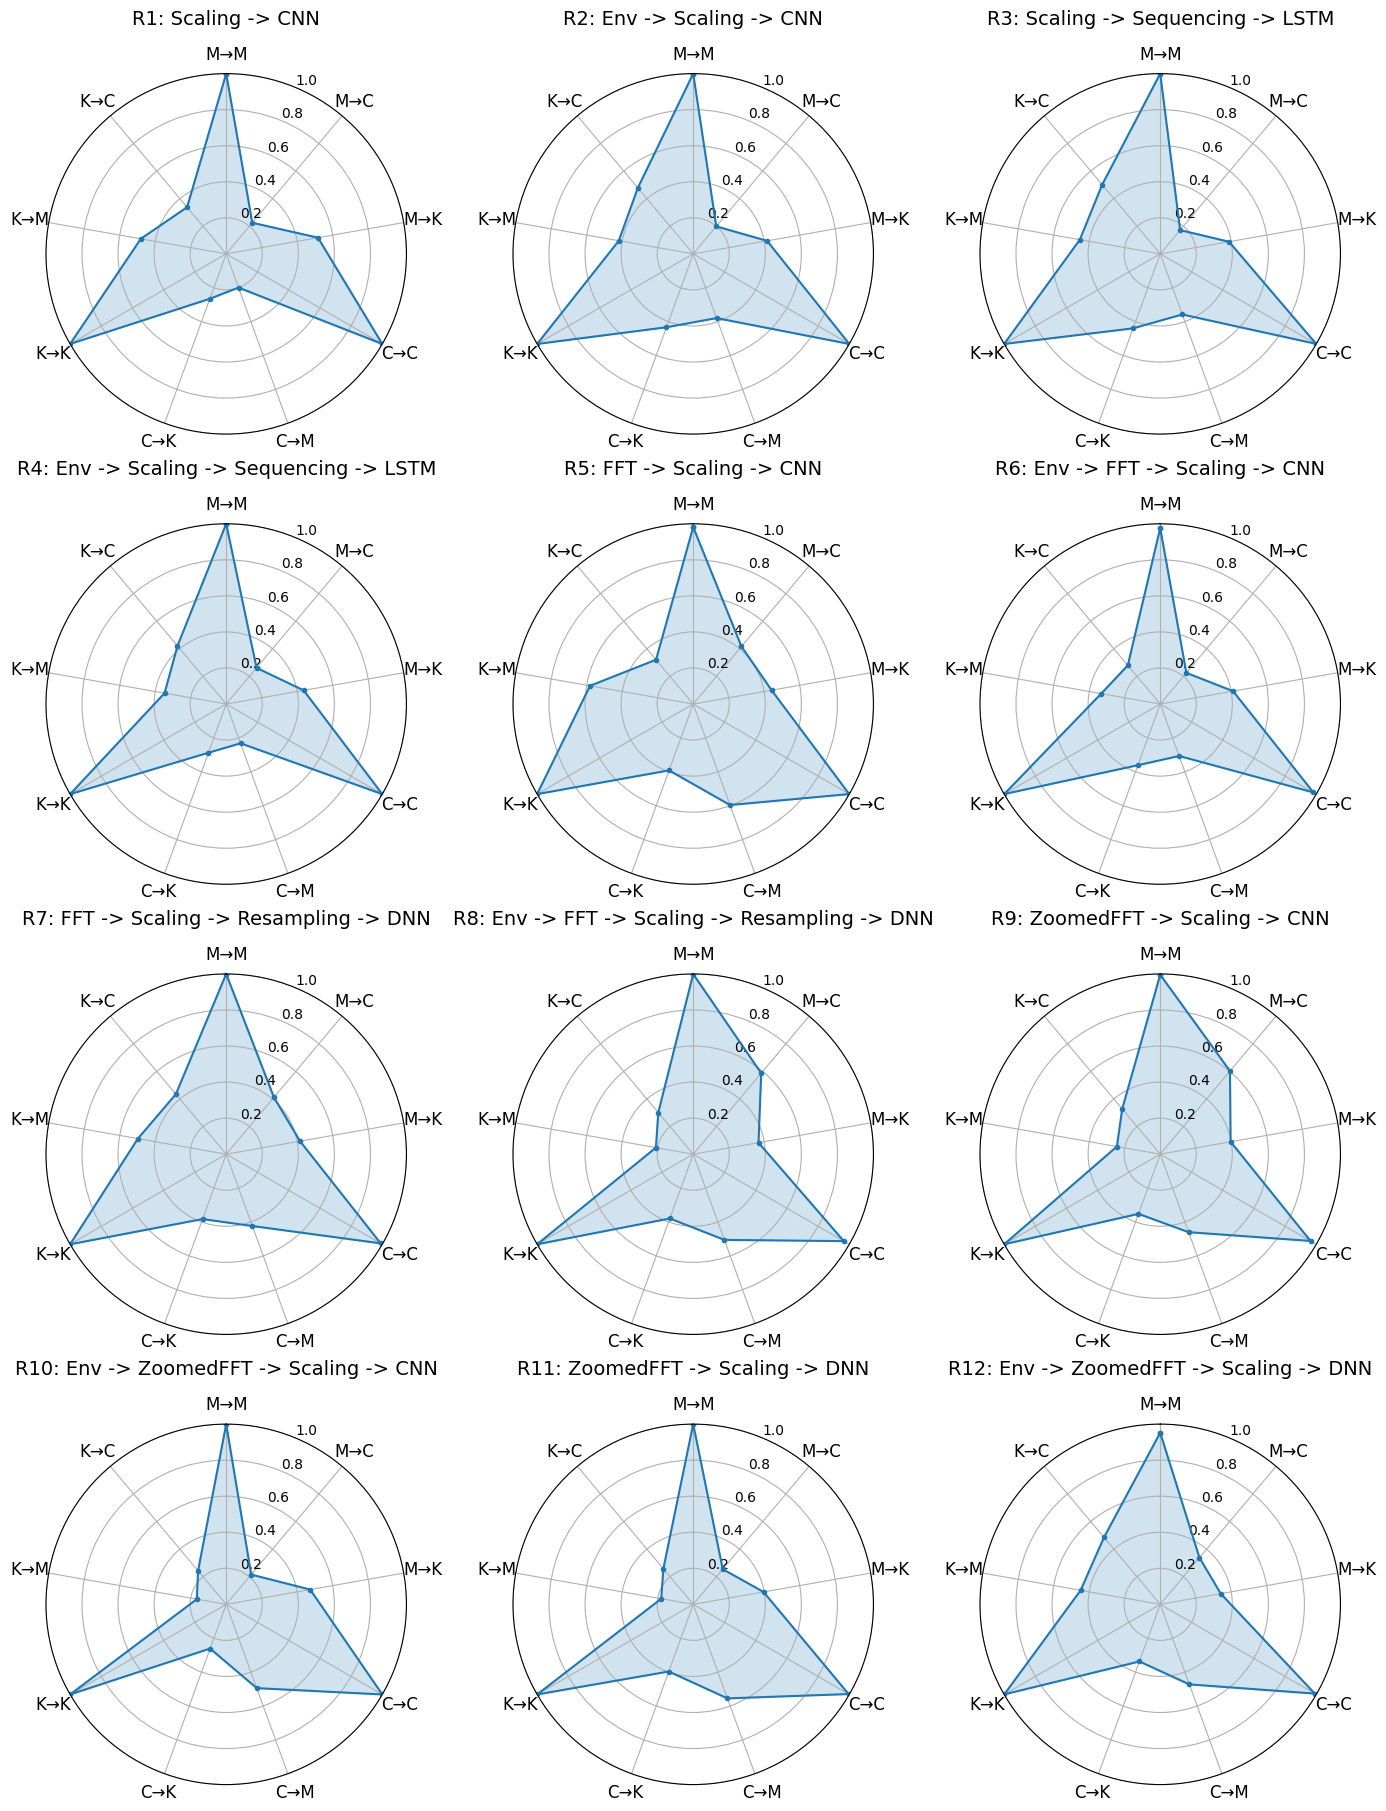

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 9 training combinations
# ---------------------------------------------------

combinations = ["M→M", "M→C", "M→K", "C→C", "C→M", "C→K", "K→K", "K→M", "K→C"]

num_vars = len(combinations)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]


# ---------------------------------------------------
# Training accuracy values (from Excel)
# Order:
# [M→M, M→C, M→K, C→C, C→M, C→K, K→K, K→M, K→C]
# ---------------------------------------------------

data_raw = {
    "R1": [1.0000, 0.2252, 0.5168, 0.9998, 0.1993, 0.2652, 1.0000, 0.4811, 0.3377],
    "R2": [1.0000, 0.1990, 0.4161, 1.0000, 0.3794, 0.4334, 1.0000, 0.4192, 0.4778],
    "R3": [1.0000, 0.1720, 0.3876, 0.9991, 0.3580, 0.4399, 1.0000, 0.4527, 0.5009],
    "R4": [1.0000, 0.2618, 0.4363, 1.0000, 0.2320, 0.2876, 1.0000, 0.3473, 0.4206],
    "R5": [0.9815, 0.4167, 0.4415, 0.9993, 0.5964, 0.3918, 1.0000, 0.5815, 0.3209],
    "R6": [0.9758, 0.2258, 0.4105, 0.9813, 0.3068, 0.3613, 0.9993, 0.3324, 0.2797],
    "R7": [1.0000, 0.4118, 0.4158, 0.9897, 0.4242, 0.3831, 1.0000, 0.4975, 0.4345],
    "R8": [0.9993, 0.5868, 0.3679, 0.9650, 0.5060, 0.3796, 0.9998, 0.2100, 0.3016],
    "R9": [0.9957, 0.6022, 0.3967, 0.9629, 0.4605, 0.3524, 1.0000, 0.2441, 0.3279],
    "R10": [1.0000, 0.2156, 0.4729, 1.0000, 0.4947, 0.2611, 1.0000, 0.1658, 0.2429],
    "R11": [1.0000, 0.2549, 0.3961, 0.9955, 0.5552, 0.3965, 1.0000, 0.1801, 0.2577],
    "R12": [0.9523, 0.3385, 0.3411, 0.9904, 0.4726, 0.3373, 0.9990, 0.4484, 0.4852],
}


# ---------------------------------------------------
# Routine titles
# ---------------------------------------------------

routine_names = [
    "R1: Scaling -> CNN",
    "R2: Env -> Scaling -> CNN",
    "R3: Scaling -> Sequencing -> LSTM",
    "R4: Env -> Scaling -> Sequencing -> LSTM",
    "R5: FFT -> Scaling -> CNN",
    "R6: Env -> FFT -> Scaling -> CNN",
    "R7: FFT -> Scaling -> Resampling -> DNN",
    "R8: Env -> FFT -> Scaling -> Resampling -> DNN",
    "R9: ZoomedFFT -> Scaling -> CNN",
    "R10: Env -> ZoomedFFT -> Scaling -> CNN",
    "R11: ZoomedFFT -> Scaling -> DNN",
    "R12: Env -> ZoomedFFT -> Scaling -> DNN",
]


# ---------------------------------------------------
# Radar drawing function
# ---------------------------------------------------


def draw_radar(ax, title, acc_data):

    values = acc_data + acc_data[:1]

    ax.plot(
        angles,
        values,
        color="#1f77b4",
        linewidth=1.5,
        marker=".",
        label="Training Accuracy",
    )

    ax.fill(angles, values, color="#1f77b4", alpha=0.2)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_thetagrids(np.degrees(angles[:-1]), combinations, fontsize=12)

    ax.set_ylim(0, 1)

    ax.set_title(title, size=14, pad=15)


# ---------------------------------------------------
# Create subplot grid
# ---------------------------------------------------

fig, axes = plt.subplots(
    4, 3, figsize=(14, 18), subplot_kw=dict(projection="polar"), layout="constrained"
)

plt.subplots_adjust(hspace=1.0, wspace=1.0)


# ---------------------------------------------------
# Plot all routines
# ---------------------------------------------------

for i, ax in enumerate(axes.flatten()):
    r_key = f"R{i + 1}"

    draw_radar(ax, routine_names[i], data_raw[r_key])


# ---------------------------------------------------
# Save + show
# ---------------------------------------------------

plt.savefig("conv_training_accuracy.png", dpi=500)

plt.show()


/tmp/ipykernel_4044910/574274034.py:96: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=1.0, wspace=1.0)


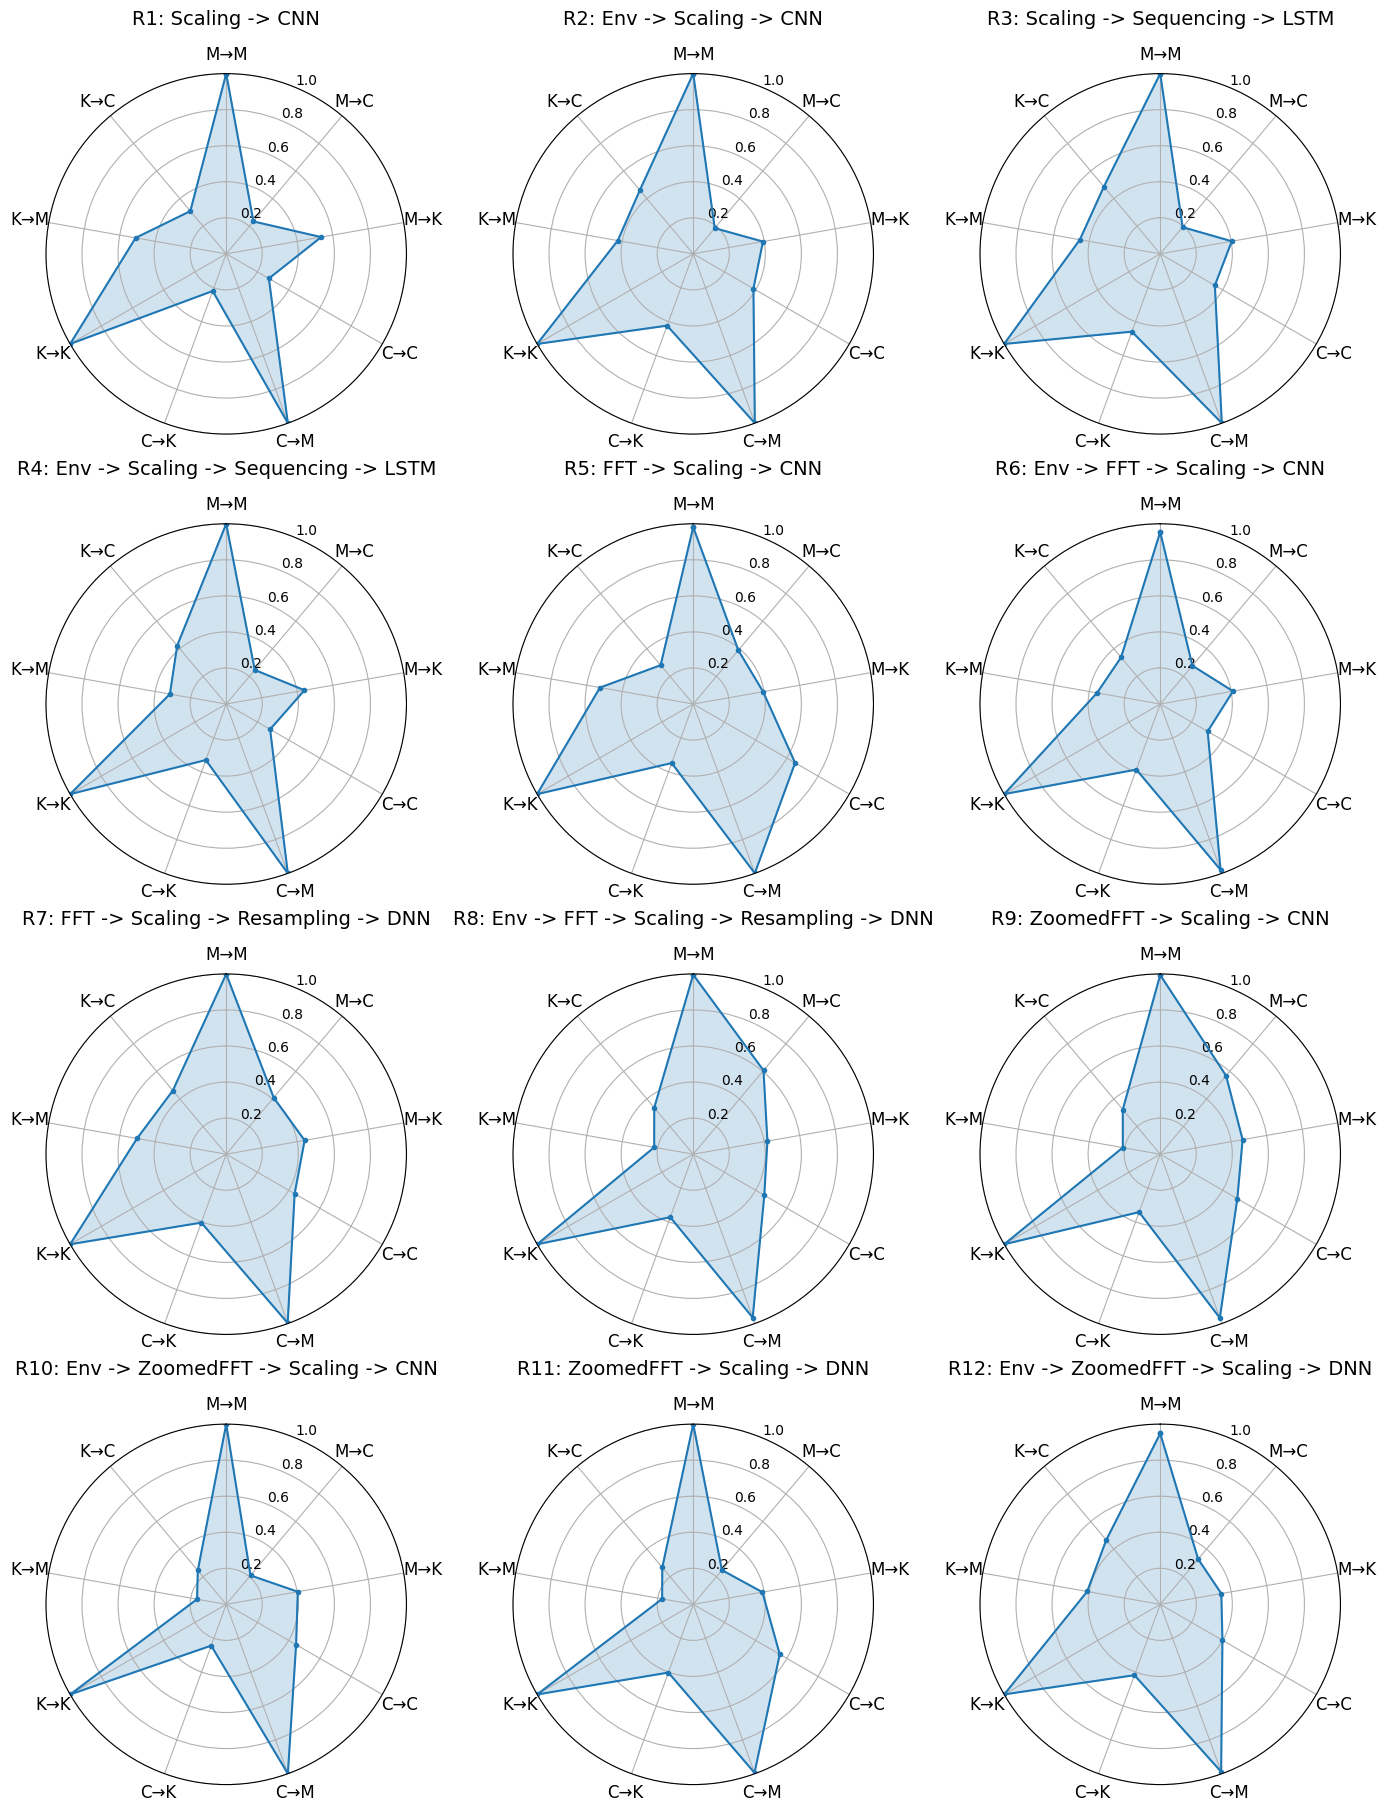

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 9 training combinations
# ---------------------------------------------------

combinations = ["M→M", "M→C", "M→K", "C→C", "C→M", "C→K", "K→K", "K→M", "K→C"]

num_vars = len(combinations)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]


# ---------------------------------------------------
# Training accuracy values (from Excel)
# Order:
# [M→M, M→C, M→K, C→C, C→M, C→K, K→K, K→M, K→C]
# ---------------------------------------------------

data_raw = {
    "R1": [1.0000, 0.2348, 0.5352, 0.2733,	1.0000,	0.2195, 1.0000, 0.5103, 0.3097],
    "R2": [1.0000, 0.1859, 0.3930, 0.3858,	0.9997,	0.4238,	1.0000, 0.4249,	0.4608],
    "R3": [1.0000, 0.1935, 0.4030, 0.3502,	0.9995,	0.4594,	1.0000, 0.4527,	0.4864],
    "R4": [1.0000, 0.2467, 0.4410, 0.2811,	1.0000,	0.3308,	1.0000, 0.3174,	0.4232],
    "R5": [0.9815, 0.3895, 0.3937, 0.6527,	0.9993,	0.3486,	1.0000, 0.5253,	0.2812],
    "R6": [0.9544, 0.2778, 0.4100, 0.3039,  0.9796,	0.3871,	0.9994, 0.3559,	0.3379],
    "R7": [0.9993, 0.4098, 0.4417, 0.4384,	0.9971,	0.4041,	0.9998, 0.5025,	0.4608],
    "R8": [0.9957, 0.6067, 0.4180, 0.4555,	0.9650,	0.3722,	1.0000, 0.2199, 0.3365],
    "R9": [0.9943, 0.5686, 0.4642, 0.4940,	0.9669,	0.3420,	0.9999, 0.2107,	0.3231],
    "R10": [1.0000, 0.2096,	0.4033, 0.4477,	1.0000,	0.2438,	1.0000, 0.1644,	0.2453],
    "R11": [1.0000,	0.2479,	0.3896, 0.5544,	0.9945,	0.4028,	1.0000, 0.1751,	0.2670],
    "R12": [0.9480,	0.3276,	0.3443, 0.3986,	0.9885,	0.4182,	0.9992, 0.4114,	0.4659]
}


# ---------------------------------------------------
# Routine titles
# ---------------------------------------------------

routine_names = [
    "R1: Scaling -> CNN",
    "R2: Env -> Scaling -> CNN",
    "R3: Scaling -> Sequencing -> LSTM",
    "R4: Env -> Scaling -> Sequencing -> LSTM",
    "R5: FFT -> Scaling -> CNN",
    "R6: Env -> FFT -> Scaling -> CNN",
    "R7: FFT -> Scaling -> Resampling -> DNN",
    "R8: Env -> FFT -> Scaling -> Resampling -> DNN",
    "R9: ZoomedFFT -> Scaling -> CNN",
    "R10: Env -> ZoomedFFT -> Scaling -> CNN",
    "R11: ZoomedFFT -> Scaling -> DNN",
    "R12: Env -> ZoomedFFT -> Scaling -> DNN",
]


# ---------------------------------------------------
# Radar drawing function
# ---------------------------------------------------


def draw_radar(ax, title, acc_data):

    values = acc_data + acc_data[:1]

    ax.plot(
        angles,
        values,
        color="#1f77b4",
        linewidth=1.5,
        marker=".",
        label="Training Accuracy",
    )

    ax.fill(angles, values, color="#1f77b4", alpha=0.2)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_thetagrids(np.degrees(angles[:-1]), combinations, fontsize=12)

    ax.set_ylim(0, 1)

    ax.set_title(title, size=14, pad=15)


# ---------------------------------------------------
# Create subplot grid
# ---------------------------------------------------

fig, axes = plt.subplots(
    4, 3, figsize=(14, 18), subplot_kw=dict(projection="polar"), layout="constrained"
)

plt.subplots_adjust(hspace=1.0, wspace=1.0)


# ---------------------------------------------------
# Plot all routines
# ---------------------------------------------------

for i, ax in enumerate(axes.flatten()):
    r_key = f"R{i + 1}"

    draw_radar(ax, routine_names[i], data_raw[r_key])


# ---------------------------------------------------
# Save + show
# ---------------------------------------------------

plt.savefig("db_training_accuracy.png", dpi=500)

plt.show()
